# **1. Introduction**

This project is about prediction of customer churn in banking industry with machine learning techniques. The workflow consists of data preprocessing, exploratory data analysis, feature engineering, predictive modelling, hyperparameter tuning, model interpretation and business intelligence preparation for integration into a Tableau dashboard.



# **2. Importing Required Libraries**

The necessary Python libraries were imported to manipulate the data, visualize and implement any machine learning models. For data handling, Pandas and NumPy were utilized, for data visualization and exploratory data analysis, Seaborn, Matplotlib and Plotly were used

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# **3. Loading the Dataset**



In [41]:
df = pd.read_csv('bankChurn.csv')


#import pandas as pd

#url = "https://raw.githubusercontent.com/RAJDONDA89/Bank_Customer_Churn_Prediction/main/data/Bank_Churn.csv"

#df = pd.read_csv(url)

#df_original = df.copy()



Pandas was used to load the banking customer churn data into the Python environment. The data was first explored to get insight into the structure of the data, what types of variables it contains and what the general composition is.

# **4. Initial Data Exploration**

In [42]:
df.head(20)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0




The data set was explored using basic functions like `head()`, `info()` and `describe()`. This has reduced the amount of records, data types, summary statistics and possible pre-processing needed prior to modelling.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [44]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# **5. Exploratory Data Analysis (EDA)**

EDA was performed to find patterns, trends, and the relationships between the customer attributes and the churn behaviour. Visual analysis was used to gain insight into demographic, financial and behavioural factors of churned and retained customers.

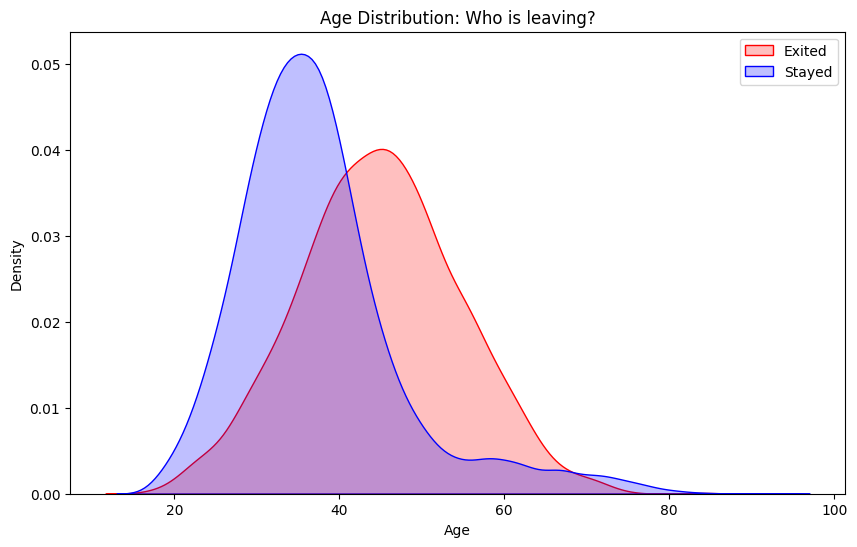

In [45]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Exited'] == 1]['Age'], label='Exited', fill=True, color='red')
sns.kdeplot(df[df['Exited'] == 0]['Age'], label='Stayed', fill=True, color='blue')
plt.title('Age Distribution: Who is leaving?')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

## **5.1 Geographical Distribution**

In [46]:
fig = px.pie(df,names="Geography",title="Country")
fig.show()



The distribution of customers was analysed using a pie chart. This helped the identification of the composition of the customers from France, Germany and Spain.

## **5.2 Gender Distribution Analysis**

In [47]:
fig = px.pie(df,names="Gender",title="Gender Distribution", color_discrete_map={'Male':'cyan', 'Female':'black'})
fig.show()

## **5.3 Correlation Heatmap Analysis**

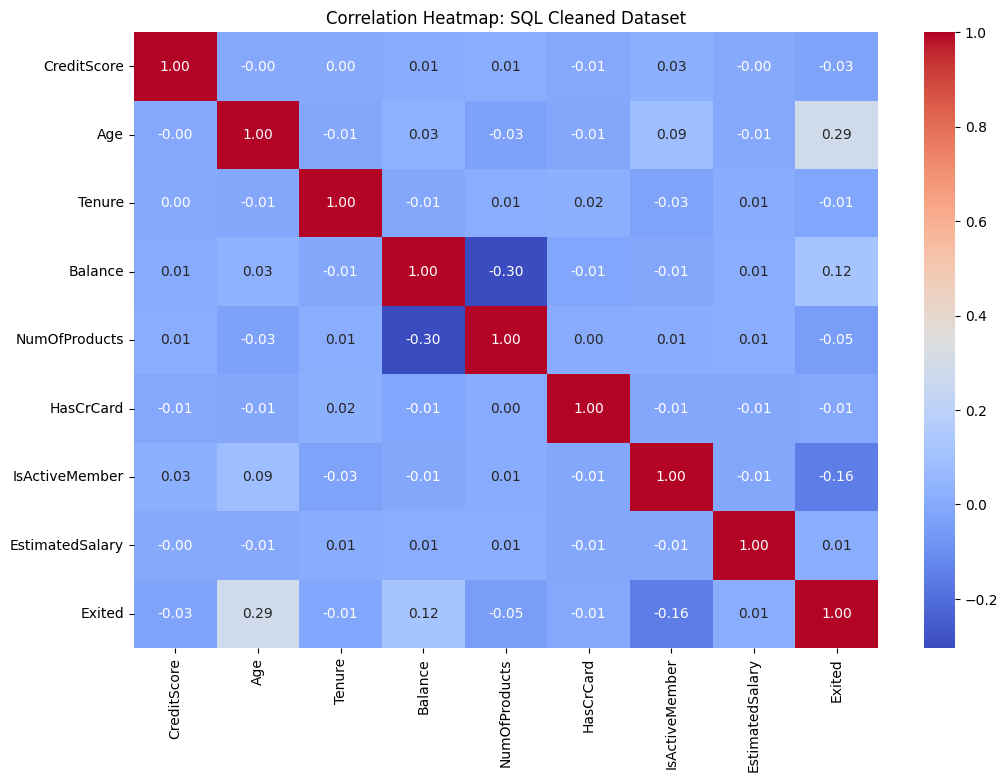

In [48]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: SQL Cleaned Dataset')
plt.show()

## **5.4 Product Usage Analysis**

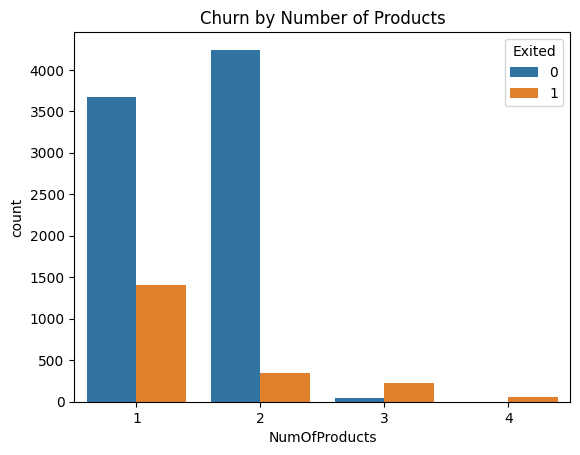

In [49]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.title('Churn by Number of Products')
plt.show()

The churn behavior of the customers was analysed using a countplot and the number of banking products was used as the variable. This helped to establish whether a customer's behavior in terms of ownership of the product had an impact on the retention rate.

# **6.Data Preprocessing**

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_score

Data preprocessing was performed to prepare the dataset for machine learning modelling. Non-predictive variables were removed, categorical variables were encoded and additional engineered features were created to improve predictive performance.

## **6.1 Removing Non-Predictive Features**

In [51]:
# Drop non-predictive columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, errors='ignore')

Data preprocessing was performed to prepare the dataset for machine learning modelling. Non-predictive variables were removed, categorical variables were encoded and additional engineered features were created to improve predictive performance.

## **6.2 One-Hot Encoding of Categorical Variables**

In [52]:
# This turns text columns into 1s and 0s
df_ml = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

Categorical variables including Geography and Gender were transformed into numerical format using One-Hot Encoding. The parameter `drop_first=True` was applied to avoid the dummy variable trap and reduce multicollinearity.

In [53]:
df_ml.head(20)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
5,645,44,8,113755.78,2,1,0,149756.71,1,False,True,True
6,822,50,7,0.00,2,1,1,10062.80,0,False,False,True
7,376,29,4,115046.74,4,1,0,119346.88,1,True,False,False
8,501,44,4,142051.07,2,0,1,74940.50,0,False,False,True
9,684,27,2,134603.88,1,1,1,71725.73,0,False,False,True


# **7. Feature Engineering**

Additional engineered features were created to improve the predictive capability of the machine learning models and capture more complex customer behaviour patterns.

## **7.1 Creating Engineered Features**

In [54]:

# 1. Balance to Salary Ratio: Does the customer have high liquidity compared to their income?
df_ml['Balance_Salary_Ratio'] = df_ml['Balance'] / (df_ml['EstimatedSalary'] + 0.001) # Add 0.001 to prevent divide-by-zero

# 2. Tenure to Age Ratio: How much of their life have they spent with the bank?
df_ml['Tenure_Age_Ratio'] = df_ml['Tenure'] / df_ml['Age']

# 3. Credit Score to Age Ratio: Financial stability relative to age
df_ml['CreditScore_Age_Ratio'] = df_ml['CreditScore'] / df_ml['Age']

# 4. The "Product Paradox" Flag: Explicitly flag customers with 3 or more products based on our EDA
df_ml['Is_MultiProduct_Risk'] = df_ml['NumOfProducts'].apply(lambda x: 1 if x >= 3 else 0)

print("Feature Engineering Complete. New shape:", df_ml.shape)

Feature Engineering Complete. New shape: (10000, 16)


Several new features were developed to strengthen predictive modelling. These included balance-to-salary ratio, tenure-to-age ratio, credit-score-to-age ratio and a custom multi-product risk indicator based on exploratory data analysis findings.

# **8.Train-Test Split and Feature Scaling**

In [55]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

In [56]:
# this ddefine Features (X) and Target (y)
X = df_ml.drop('Exited', axis=1)
y = df_ml['Exited']

In [57]:
# Train/Test Split with Stratify (crucial for our 80/20 imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

The dataset was divided into training and testing subsets using an 80/20 split. Stratified sampling was applied to preserve the original class distribution because the dataset contains class imbalance between churned and retained customers.

## **8. Feature Scaling**

In [58]:
# Feature Scaling (Fit on train only to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

Feature scaling was performed using `StandardScaler` to standardise numerical variables and improve machine learning performance. The scaler was fitted only on the training dataset to avoid data leakage.

# **9. Model Comparison**

In [80]:
#models
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

Three machine learning classification algorithms were evaluated in this project: Logistic Regression, Random Forest and Gradient Boosting. The purpose of this comparison was to evaluate the predictive performance of linear and ensemble learning approaches on customer churn prediction.

## **9.1 Model Evaluation Metrics**

In [81]:
# We use the best model(Gradient Boosting) to predict for everyone
performance_report = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
print("--- Model Performance Comparison ---")
print(performance_report)

--- Model Performance Comparison ---
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
2    Gradient Boosting    0.8690   0.784314  0.491400  0.604230  0.870343
1        Random Forest    0.8605   0.785714  0.432432  0.557845  0.853066
0  Logistic Regression    0.7535   0.438218  0.749386  0.553037  0.837588


The machine learning models were evaluated using Precision, Recall, F1-Score and ROC-AUC. These metrics provided a balanced evaluation of classification performance, particularly for the imbalanced churn dataset.

# **10. Hyperparameter Tuning**

Hyperparameter tuning was performed on the Gradient Boosting model using RandomizedSearchCV to improve predictive performance and optimise selected parameters.

In [61]:
# --- HYPERPARAMETER TUNING & CROSS-VALIDATION ---
print("Starting Hyperparameter Tuning for Gradient Boosting...")

Starting Hyperparameter Tuning for Gradient Boosting...


## **10.1 Stratified Cross-Validation**

In [62]:
# Define the grid of parameters to test
param_grid = {
    'n_estimators': [100, 200, 300],          # Number of trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size
    'max_depth': [3, 4, 5, 6],                # How deep each tree can grow
    'subsample': [0.8, 0.9, 1.0]              # Fraction of samples used per tree (prevents overfitting)
}

# 5-Fold Stratified Cross-Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize base model and Random Search
gb_base = GradientBoostingClassifier(random_state=42)
gb_tuned = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_grid,
    n_iter=15,               # Tests 15 random combinations
    scoring='roc_auc',       # Optimizing for ROC-AUC
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1                # Uses all processor cores to speed up
)

In [63]:
gb_tuned.fit(X_train_scaled, y_train)
best_model = gb_tuned.best_estimator_

print("Tuning Complete!")
print("Best Parameters:", gb_tuned.best_params_)
print("Best Cross-Validation ROC-AUC:", round(gb_tuned.best_score_, 4))

Tuning Complete!
Best Parameters: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}
Best Cross-Validation ROC-AUC: 0.8602


Five-fold Stratified Cross-Validation was used during model tuning to ensure stable performance across multiple data splits and reduce the risk of overfitting.

# **11. Model Evaluation**

In [64]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [65]:
# --- ADVANCED EVALUATION ---
predictions = best_model.predict(X_test_scaled)
probs = best_model.predict_proba(X_test_scaled)[:, 1]



The tuned Gradient Boosting model was evaluated on unseen testing data using classification metrics and confusion matrix analysis.

 ## **11.1 Classification Report**

In [66]:
# 1. Classification Report (Shows Precision, Recall, F1 for BOTH classes)
print("--- Classification Report ---")
print(classification_report(y_test, predictions))
print(f"Final Test ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}\n")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.79      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000

Final Test ROC-AUC Score: 0.8663



## **11.2 Confusion Matrix Analysis**

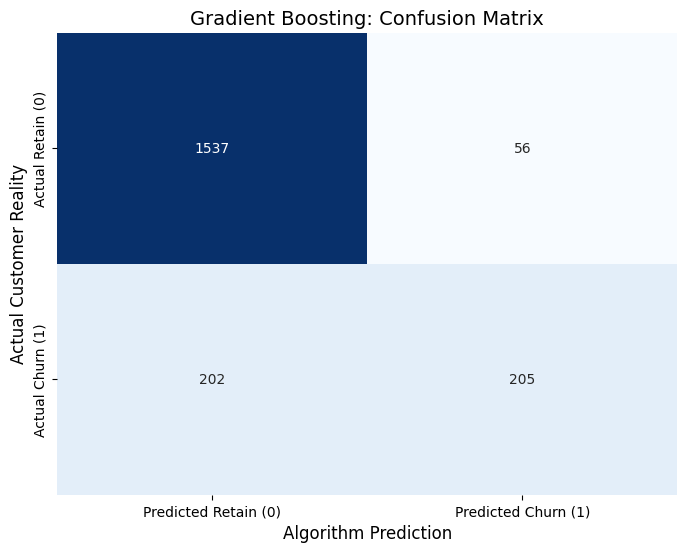

In [67]:
# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Retain (0)', 'Predicted Churn (1)'],
            yticklabels=['Actual Retain (0)', 'Actual Churn (1)'])
plt.title('Gradient Boosting: Confusion Matrix', fontsize=14)
plt.xlabel('Algorithm Prediction', fontsize=12)
plt.ylabel('Actual Customer Reality', fontsize=12)
plt.show()



A confusion matrix heatmap was generated to visualise correctly classified and misclassified customers. This helped analyse the strengths and weaknesses of the churn prediction model.

In [68]:
!pip install shap

# **12. SHAP Analysis**

In [69]:
# --- SHAP INTERPRETATION ANALYSIS ---
print("Generating SHAP values to explain model logic...")

Generating SHAP values to explain model logic...




SHAP (SHapley Additive Explanations) analysis was performed to interpret the internal decision-making behaviour of the tuned Gradient Boosting model.

In [70]:
import shap

# Initialize the Tree Explainer for our tuned Gradient Boosting model
explainer = shap.TreeExplainer(best_model)

In [71]:
# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

## **12.1 SHAP Feature Importance**

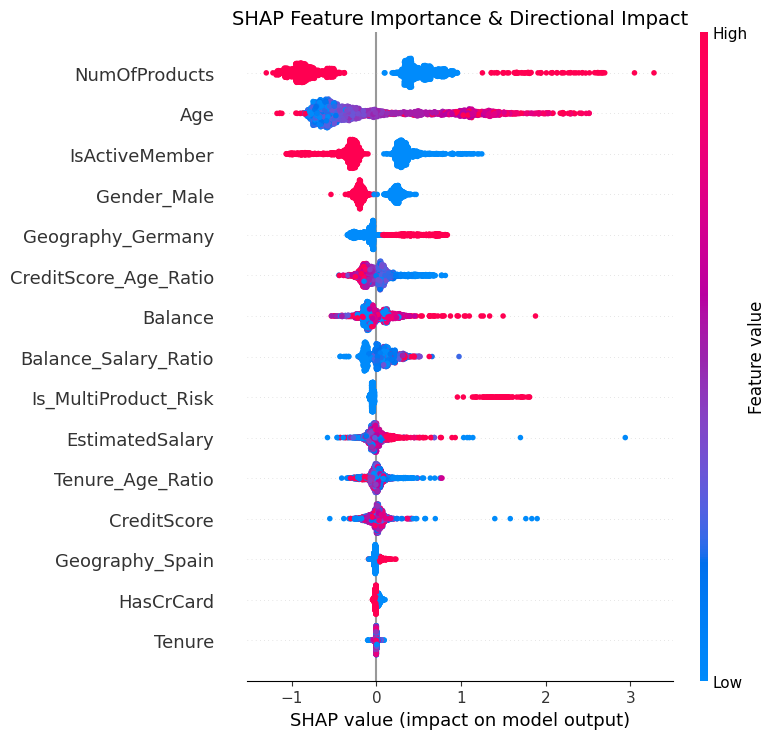

In [72]:
# Plot the SHAP Summary Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance & Directional Impact", fontsize=14)
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot")



The SHAP summary plot was used to identify the most influential variables affecting churn prediction and to understand the directional impact of each feature on model predictions.

# **13. Final Deployment and Risk Segmentation**



The final tuned model was applied to the complete dataset to generate customer-level churn probability predictions for business intelligence integration.

In [73]:
# --- FINAL DEPLOYMENT: PREDICTING FOR THE ENTIRE DATASET ---
print("Generating final predictions for the Tableau Dashboard...")


Generating final predictions for the Tableau Dashboard...


In [74]:
# 1. Scale the ENTIRE dataset (using the scaler we strictly fitted on the training data earlier)
X_all_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns)


In [75]:
# 2. Predict probabilities for every single customer using our newly tuned model
full_probs = best_model.predict_proba(X_all_scaled)[:, 1]


In [76]:
# 3. Load the original raw data so the business has readable columns (like Surname, Geography)
df_final = pd.read_csv('Churn_Modelling.csv')


In [77]:
# 4. Append our predictive intelligence
df_final['Churn_Probability'] = full_probs


## **13.1 Customer Risk Segmentation**

In [78]:
# 5. Apply the business logic threshold to create actionable Risk Segments
df_final['Risk_Segment'] = df_final['Churn_Probability'].apply(
    lambda x: 'Critical' if x > 0.7 else ('Medium' if x > 0.4 else 'Low')
)

## **13.2 Exporting Final Dataset**

In [79]:

# 6. Export the final dataset
df_final.to_csv('Final_Churn_Predictions.csv', index=False)
print("\nSuccess! 'Final_Churn_Predictions.csv' has been generated and is ready for Tableau.")


Success! 'Final_Churn_Predictions.csv' has been generated and is ready for Tableau.




The final dataset containing churn probabilities and customer risk segments was exported as a CSV file for Tableau dashboard integration and business intelligence visualisation.